In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error

In [18]:
df = pd.read_csv('data/wage.csv')
df

,id,nearc2,nearc4,educ,age,fatheduc,motheduc,weight,momdad14,sinmom14,step14,reg661,reg662,reg663,reg664,reg665,reg666,reg667,reg668,reg669,south66,black,smsa,south,smsa66,wage,enroll,KWW,IQ,married,libcrd14,exper,lwage,expersq
0,2,0,0,7,29,NaN,NaN,158413,1,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,548,0,15.0,NaN,1.0,0.0,16,"6,306274891",256
1,3,0,0,12,27,8.0,8.0,380166,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,481,0,35.0,93.0,1.0,1.0,9,"6,175867081",81
2,4,0,0,12,34,14.0,12.0,367470,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,721,0,42.0,103.0,1.0,1.0,16,"6,580638885",256
3,5,1,1,11,27,11.0,12.0,380166,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,250,0,25.0,88.0,1.0,1.0,10,"5,52146101",100
4,6,1,1,12,34,8.0,7.0,367470,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,729,0,34.0,108.0,1.0,0.0,16,"6,591673851",256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3005,5218,0,1,12,25,8.0,12.0,82135,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,335,0,15.0,NaN,1.0,0.0,7,"5,814129829",49
3006,5219,0,1,13,34,NaN,NaN,88765,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,0,481,0,43.0,NaN,1.0,1.0,15,"6,175867081",225
3007,5220,0,1,12,24,11.0,NaN,89271,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,500,0,25.0,109.0,1.0,0.0,6,"6,214608192",36
3008,5221,0,1,12,31,NaN,NaN,110376,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,713,0,32.0,107.0,1.0,1.0,13,"6,569480896",169


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3010 entries, 0 to 3009
Data columns (total 34 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        3010 non-null   int64  
 1   nearc2    3010 non-null   int64  
 2   nearc4    3010 non-null   int64  
 3   educ      3010 non-null   int64  
 4   age       3010 non-null   int64  
 5   fatheduc  2320 non-null   float64
 6   motheduc  2657 non-null   float64
 7   weight    3010 non-null   int64  
 8   momdad14  3010 non-null   int64  
 9   sinmom14  3010 non-null   int64  
 10  step14    3010 non-null   int64  
 11  reg661    3010 non-null   int64  
 12  reg662    3010 non-null   int64  
 13  reg663    3010 non-null   int64  
 14  reg664    3010 non-null   int64  
 15  reg665    3010 non-null   int64  
 16  reg666    3010 non-null   int64  
 17  reg667    3010 non-null   int64  
 18  reg668    3010 non-null   int64  
 19  reg669    3010 non-null   int64  
 20  south66   3010 non-null   int64  
 21  bl

In [20]:
feature_cols = ['exper', 'expersq', 'black', 'south66', 'enroll', 'smsa',
                'momdad14', 'weight', 'wage', 'libcrd14', 'motheduc', 'fatheduc',
                'KWW', 'IQ']

temp = df[feature_cols]
temp.isnull().sum()

exper         0
expersq       0
black         0
south66       0
enroll        0
smsa          0
momdad14      0
weight        0
wage          0
libcrd14     13
motheduc    353
fatheduc    690
KWW          47
IQ          949
dtype: int64

In [21]:
null_cols = ['libcrd14', 'motheduc', 'fatheduc', 'KWW', 'IQ']
for col in null_cols:
    temp[col] = temp[col].fillna(temp[col].mean())

temp.isnull().sum()

exper       0
expersq     0
black       0
south66     0
enroll      0
smsa        0
momdad14    0
weight      0
wage        0
libcrd14    0
motheduc    0
fatheduc    0
KWW         0
IQ          0
dtype: int64

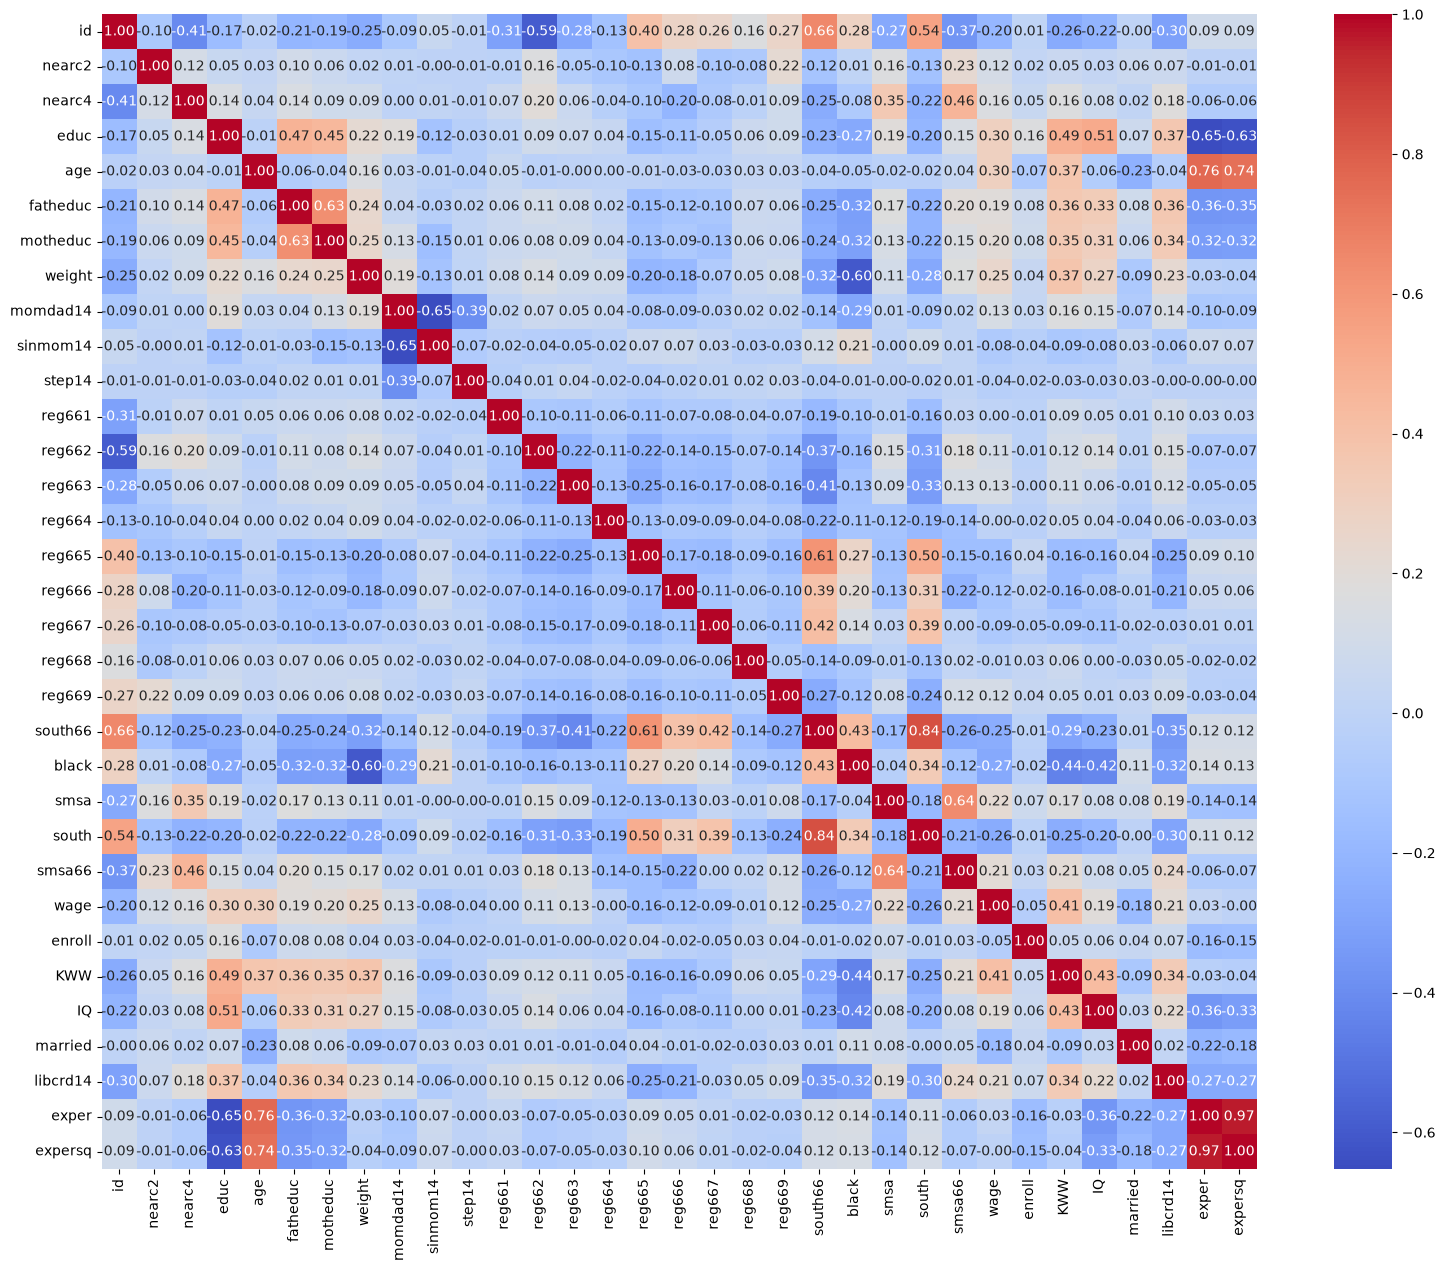

In [22]:
mat = df.corr(numeric_only=True)

plt.figure(figsize=(20,15))
sns.heatmap(
    mat,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True)

plt.show()

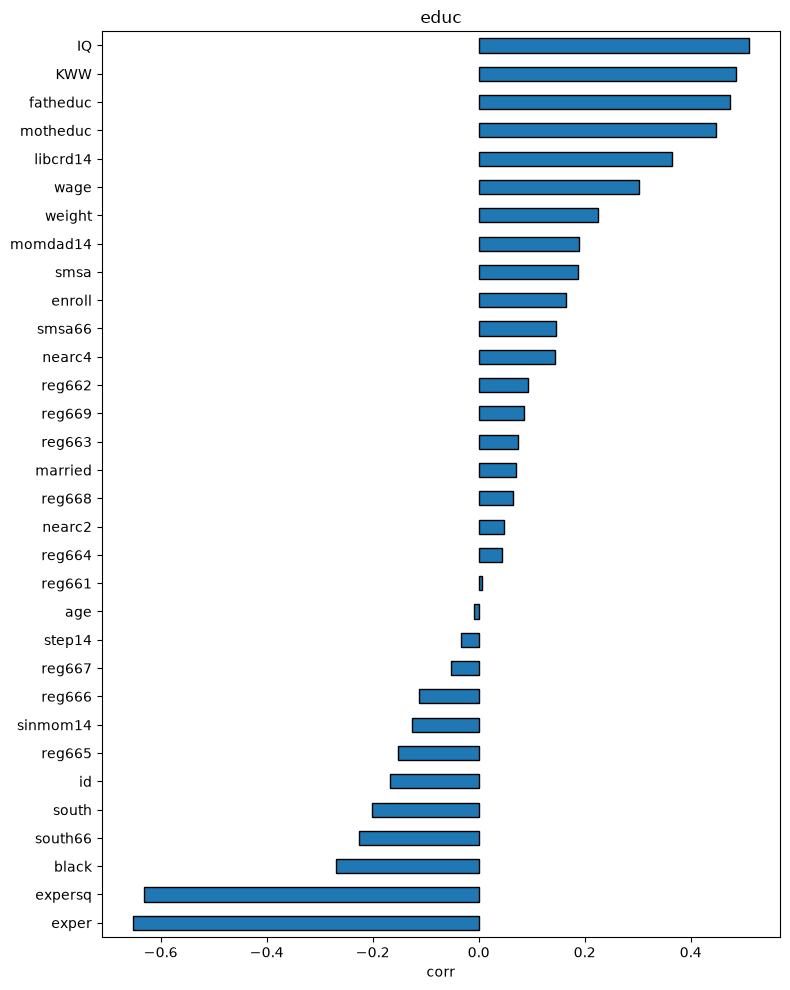

In [23]:
target_col = (
    df.corr(numeric_only=True)['educ']
    .drop('educ')
    .sort_values()
)

plt.figure(figsize=(8,10))

target_col.plot(
    kind="barh",
    edgecolor='black'
)

plt.title("educ")
plt.xlabel('corr')
plt.tight_layout()
plt.show()

In [24]:
feature_cols = ['exper', 'expersq', 'black', 'south66', 'enroll', 'smsa',
                'momdad14', 'weight', 'wage', 'libcrd14', 'motheduc', 'fatheduc',
                'KWW', 'IQ']
target = 'educ'


X = temp[feature_cols]
y = df[target]


x_train, x_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2,
                                                    random_state=42)

                                                    
sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

x_train_sc.shape, x_test_sc.shape, y_train.shape, y_test.shape

((2408, 14), (602, 14), (2408,), (602,))

In [28]:
lr_model = Ridge(
    alpha = 0.5
)

svr_model = SVR(
    kernel= 'rbf',
    epsilon= 0.01,
    C= 50
)



lr_model.fit(x_train_sc, y_train)
svr_model.fit(x_train_sc, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",50
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.01
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [29]:
lr_y_pred = lr_model.predict(x_test_sc)
svr_y_pred = svr_model.predict(x_test_sc)

print("Ridge")
print(f'r2  : {r2_score(y_test, lr_y_pred)}')
print(f'rmse: {root_mean_squared_error(y_test, lr_y_pred)}')

print("SVR")
print(f'r2  : {r2_score(y_test, svr_y_pred)}')
print(f'rmse: {root_mean_squared_error(y_test, svr_y_pred)}')

Ridge
r2  : 0.666774309840481
rmse: 1.500413952811452
SVR
r2  : 0.5836481552804642
rmse: 1.6771507575030367
